In [ ]:
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path

In [2]:
def open_json(path):
    dfs = []
    path = Path(path)

    for file in path.parent.glob(path.name):
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        rows = []
        for metric, values in data.items():
            for item in values:
                rows.append({
                    'metric': metric,
                    'ts': item['ts'],
                    'value': int(item['value'])
                })
        
        df = pd.DataFrame(rows)
        df['ts'] = pd.to_datetime(df['ts'], unit='ms')
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)


In [ ]:
base_dir = Path(os.getcwd()).resolve().parent

df = open_json(base_dir / 'data/raw/batch_*.json')
print(df.head())

                    metric                  ts  value
0  mobil_pribadi_out_delta 2025-09-04 08:00:00    156
1  mobil_pribadi_out_delta 2025-09-04 10:00:00    369
2           truk_out_delta 2025-09-04 08:00:00    277
3           truk_out_delta 2025-09-04 10:00:00    377
4         pickup_out_delta 2025-09-04 08:00:00     35


# EDA

In [5]:
import matplotlib.pyplot as plt

def line_chart(df, value='mobil_pribadi_out_delta'):
    df = df[df['metric'] == value].copy()
    
    plt.figure(figsize=(10,6))
    plt.plot(df['ts'], df['value'])
    plt.grid()
    plt.title(f'graph {value} over time')
    plt.xticks(rotation=90)

    return plt.show()

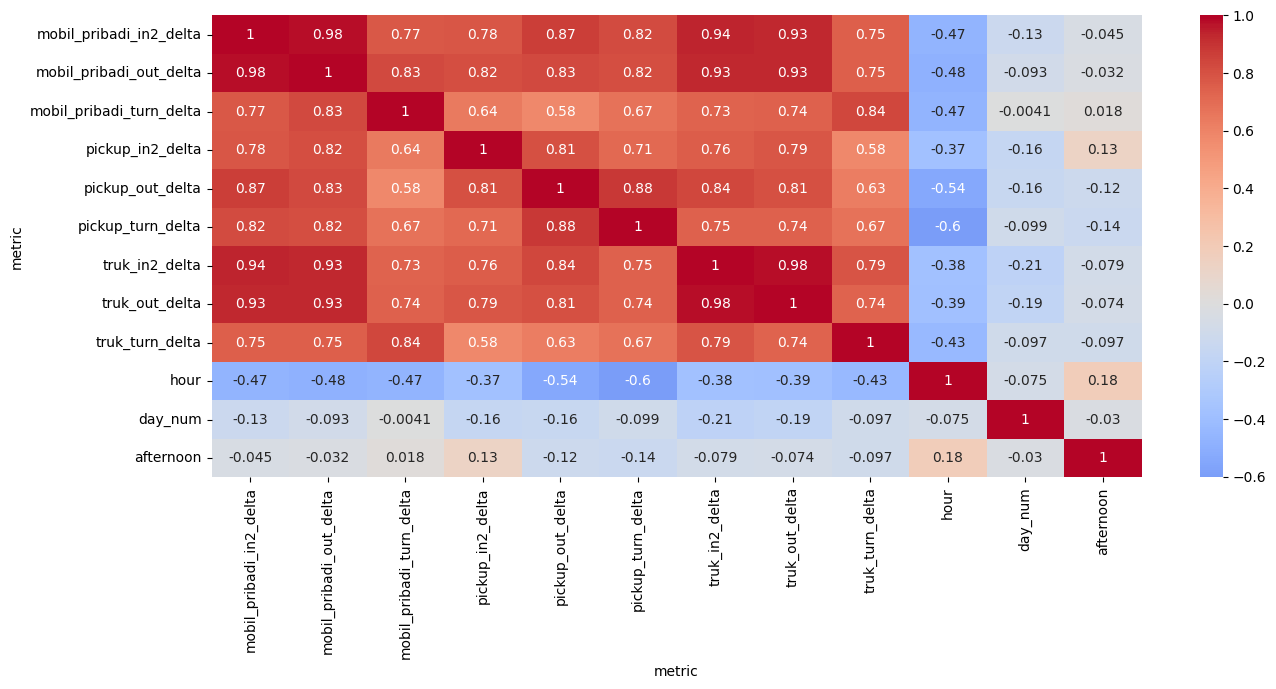

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_wide = (
    df.pivot_table(
        index='ts',
        columns='metric',
        values='value'
    )
)
df_wide['hour'] = df_wide.index.hour
df_wide['day_num'] = df_wide.index.day_of_week
df_wide['afternoon'] = np.where(
    df_wide['hour'].between(6,18), 1, 0
)

corr = df_wide.corr()
plt.figure(figsize=(15,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def box(df, x='time', obj=None):
    df = df[df['metric'].isin(obj)]
    plt.figure(figsize=(12,6))
    ax = sns.boxplot(x=df[x], y=df['value'], hue='metric', data=df, palette='Set2')
    
    plt.grid()
    if x == 'day_num' :
        plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    else:
        None
    
    plt.show()

def flag_outlier(df, value_col='value', group_col='metric'):
    df = df.copy()

    q1 = df.groupby(group_col)[value_col].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(group_col)[value_col].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df['outlier'] = ~df[value_col].between(lower, upper)
    return df

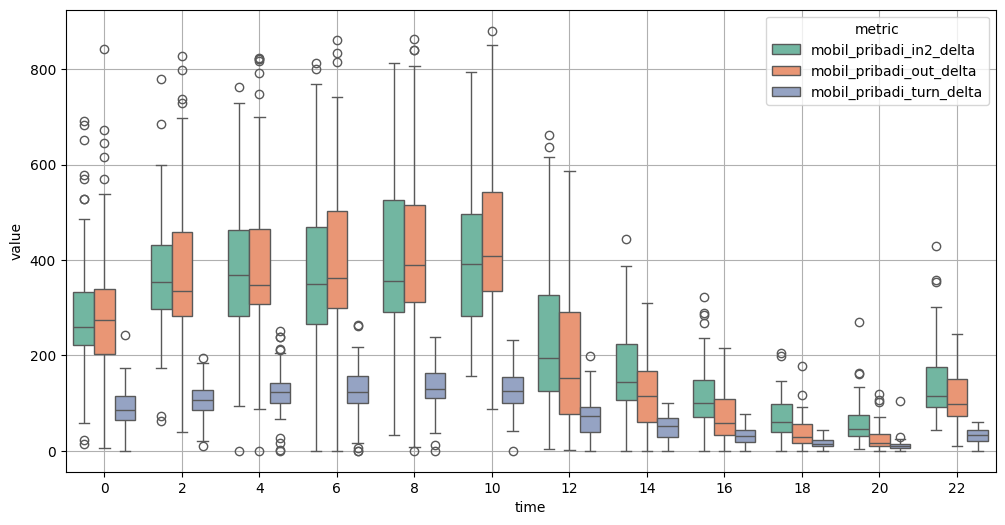

In [43]:
df2 = flag_outlier(df)
df2 = df2[df2['outlier'] == False].copy()
df2['time'] = df2['ts'].dt.hour
df2['date'] = df2['ts'].dt.date
df2['day_num'] = df2['ts'].dt.weekday

obj = ['mobil_pribadi_out_delta', 'mobil_pribadi_turn_delta', 'mobil_pribadi_in2_delta']
box(df2, obj=obj)
# box(df2, x='day_num', obj=obj)

                     metric                  ts  value  time        date  \
6   mobil_pribadi_in2_delta 2025-09-12 08:00:00    333     8  2025-09-12   
7   mobil_pribadi_in2_delta 2025-09-12 10:00:00    794    10  2025-09-12   
14  mobil_pribadi_in2_delta 2025-09-15 12:00:00    637    12  2025-09-15   
15  mobil_pribadi_in2_delta 2025-09-15 14:00:00    368    14  2025-09-15   
16  mobil_pribadi_in2_delta 2025-09-15 16:00:00    289    16  2025-09-15   

    day_num     period period2  
6         4    morning     day  
7         4    morning     day  
14        0  afternoon     day  
15        0  afternoon     day  
16        0  afternoon     day  


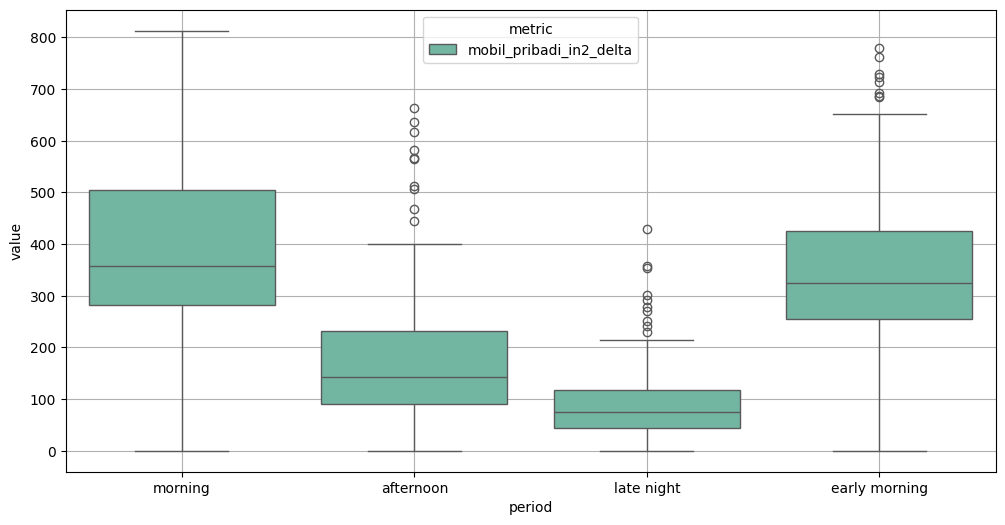

In [37]:
dp = df2.copy()

dp_cond = [
    dp['time'].between(0,4),
    dp['time'].between(6,10),
    dp['time'].between(12,16)
]
dp_res = ['early morning','morning','afternoon']

dp['period'] = np.select(dp_cond, dp_res, default='late night')
dp['period2'] = np.where(
    dp['time'].between(6, 18), 'day', 'night'
)
dp = dp.sort_values('ts')
 
mt = ['mobil_pribadi_in2_delta']
dp = dp[dp['metric'].isin(mt)]

print(dp.head())

box(dp, x='period',obj=mt)
